In [1]:
import kagglehub
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")

100%|██████████| 2.54k/2.54k [00:00<00:00, 6.24MB/s]

Extracting files...


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import os module
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# The path variable from the previous cell should contain the download directory
print(f"Checking contents of directory: {path}")
print(os.listdir(path)) # List contents of the directory to find the CSV file

# Assuming the dataset is a CSV file within the downloaded path, let's try to find it.
# Based on typical Kaggle dataset structures, the file might be directly in 'path' or a subfolder.
# From the name 'Sleep_Health_and_Lifestyle_Dataset.csv', it is likely directly there.
# If it's not, we might need to adjust based on the output of os.listdir(path).

dataset_file_name = "Sleep_Health_and_Lifestyle_Dataset.csv"
full_dataset_path = os.path.join(path, dataset_file_name)

# Check if the file exists before attempting to read
if os.path.exists(full_dataset_path):
    df = pd.read_csv(full_dataset_path)
    print("Dataset loaded successfully.")
    display(df.head())
else:
    # If the file is not directly in the path, it might be in a subfolder.
    # Let's try to find a .csv file in the listed contents.
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if csv_files:
        # Assume the first CSV file found is the correct one.
        # This is a heuristic, might need user input if multiple CSVs exist.
        print(f"Found CSV file(s): {csv_files}. Attempting to load {csv_files[0]}")
        full_dataset_path = os.path.join(path, csv_files[0])
        df = pd.read_csv(full_dataset_path)
        print("Dataset loaded successfully.")
        display(df.head())
    else:
        print(f"Error: No CSV file found in {path}")
        # You might want to raise an error or handle this case more robustly


Checking contents of directory: /root/.cache/kagglehub/datasets/uom190346a/sleep-health-and-lifestyle-dataset/versions/2
['Sleep_health_and_lifestyle_dataset.csv']
Found CSV file(s): ['Sleep_health_and_lifestyle_dataset.csv']. Attempting to load Sleep_health_and_lifestyle_dataset.csv
Dataset loaded successfully.


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [6]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [7]:
print("\nDescriptive Statistics:")
display(df.describe(include='all'))


Descriptive Statistics:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


### Data Cleaning and Preprocessing

In [8]:
# Handle missing values in 'Sleep Disorder' by filling with 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
print("Missing values in 'Sleep Disorder' handled.")
print(df['Sleep Disorder'].value_counts())

Missing values in 'Sleep Disorder' handled.
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [9]:
# Split 'Blood Pressure' into two numerical columns: Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])
df = df.drop(columns=['Blood Pressure'])
print("Blood Pressure split into Systolic_BP and Diastolic_BP.")
display(df.head())

Blood Pressure split into Systolic_BP and Diastolic_BP.


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [10]:
# Apply Label Encoding to categorical features: Gender, Occupation, BMI Category
label_encoders = {}
for column in ['Gender', 'Occupation', 'BMI Category']:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le
    print(f"'{column}' encoded.")

# Encode the target variable 'Sleep Disorder'
le_sleep_disorder = LabelEncoder()
df['Sleep Disorder'] = le_sleep_disorder.fit_transform(df['Sleep Disorder'])
print("'Sleep Disorder' encoded.")
print("Mapping of 'Sleep Disorder':", list(le_sleep_disorder.classes_))

# Drop 'Person ID' column as it's an identifier and not a feature
df = df.drop(columns=['Person ID'])
print("'Person ID' column dropped.")
display(df.head())

'Gender' encoded.
'Occupation' encoded.
'BMI Category' encoded.
'Sleep Disorder' encoded.
Mapping of 'Sleep Disorder': ['Insomnia', 'None', 'Sleep Apnea']
'Person ID' column dropped.


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,27,9,6.1,6,42,6,3,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,2,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,2,85,3000,2,140,90


### Feature Scaling and Data Splitting

In [11]:
# Define features (X) and target (y)
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data split into training (X_train shape: {X_train.shape}, y_train shape: {y_train.shape}) and testing (X_test shape: {X_test.shape}, y_test shape: {y_test.shape}) sets.")

# Scale numerical features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert y_train and y_test to one-hot encoded format for Keras
y_train_cat = to_categorical(y_train, num_classes=len(le_sleep_disorder.classes_))
y_test_cat = to_categorical(y_test, num_classes=len(le_sleep_disorder.classes_))
print("Numerical features scaled and target variable one-hot encoded.")

Data split into training (X_train shape: (299, 12), y_train shape: (299,)) and testing (X_test shape: (75, 12), y_test shape: (75,)) sets.
Numerical features scaled and target variable one-hot encoded.


### Building and Training the Deep Learning Model

In [17]:
# Define the Deep Learning Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le_sleep_disorder.classes_), activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Deep learning model defined and compiled.")
model.summary()

Deep learning model defined and compiled.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,115 (39.51 KB)

 Trainable params: 10,115 (39.51 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Train the model
history = model.fit(X_train_scaled, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

print("\nModel training complete.")

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5649 - loss: 0.9932 - val_accuracy: 0.8667 - val_loss: 0.7419
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7699 - loss: 0.7421 - val_accuracy: 0.8500 - val_loss: 0.5601
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8452 - loss: 0.5931 - val_accuracy: 0.8500 - val_loss: 0.4822
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8452 - loss: 0.5309 - val_accuracy: 0.8500 - val_loss: 0.4599
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8577 - loss: 0.4895 - val_accuracy: 0.8500 - val_loss: 0.4557
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8703 - loss: 0.4713 - val_accuracy: 0.8667 - val_loss: 0.4579
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8745 - loss: 0.4597 - val_accuracy: 0.8667 - val_loss: 0.4577
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8787 - loss: 0.4338 - val_accuracy: 0.8667 - val_loss: 0.4536


### Model Evaluation

Test Loss: 0.1286
Test Accuracy: 0.9733


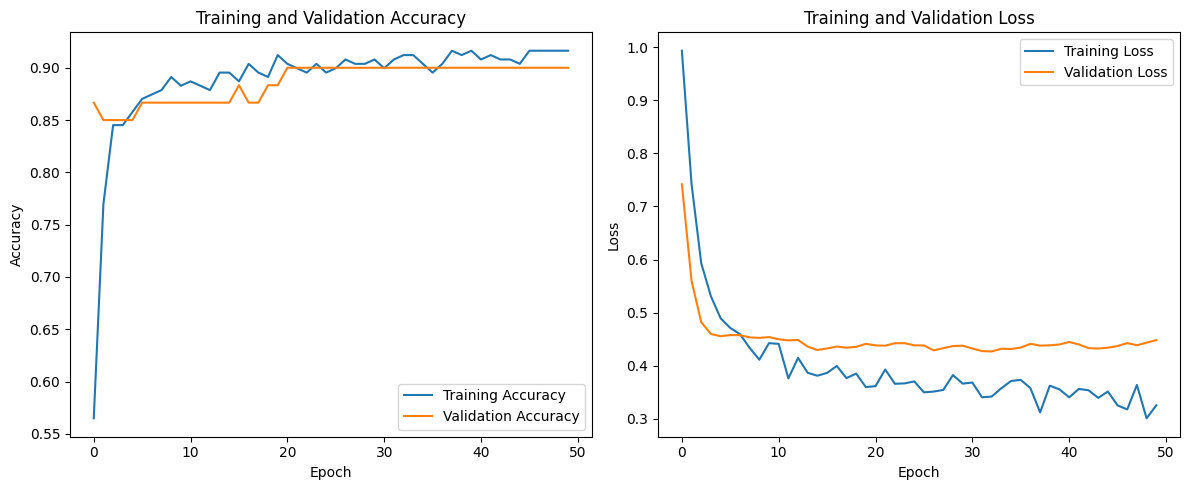

In [19]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Save Model and Preprocessing Objects

In [20]:
import joblib

# Create a directory to save the assets
output_dir = 'model_assets'
os.makedirs(output_dir, exist_ok=True)

# Save the trained Keras model
model.save(f'{output_dir}/deep_learning_model.keras')
print(f"Deep learning model saved to {output_dir}/deep_learning_model.keras")

# Save the StandardScaler
joblib.dump(scaler, f'{output_dir}/scaler.pkl')
print(f"Scaler saved to {output_dir}/scaler.pkl")

# Save the Sleep Disorder LabelEncoder
joblib.dump(le_sleep_disorder, f'{output_dir}/le_sleep_disdisorder.pkl')
print(f"Sleep Disorder LabelEncoder saved to {output_dir}/le_sleep_disdisorder.pkl")

# Save other LabelEncoders (Gender, Occupation, BMI Category)
joblib.dump(label_encoders, f'{output_dir}/other_label_encoders.pkl')
print(f"Other LabelEncoders saved to {output_dir}/other_label_encoders.pkl")

Deep learning model saved to model_assets/deep_learning_model.keras
Scaler saved to model_assets/scaler.pkl
Sleep Disorder LabelEncoder saved to model_assets/le_sleep_disdisorder.pkl
Other LabelEncoders saved to model_assets/other_label_encoders.pkl


### Streamlit Application Code

Below is the code for the Streamlit application. You should save this code to a file named `app.py` in your local environment. After saving the model and preprocessing objects (from the previous cell), ensure `app.py` is in the same directory as the `model_assets` folder, or adjust the paths accordingly.

To run this app, navigate to the directory containing `app.py` in your terminal and execute:
`streamlit run app.py`

If you don't have Streamlit installed, you can install it via pip:
`pip install streamlit`

In [21]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib
import os

# Load saved assets
@st.cache_resource
def load_assets():
    model = load_model('model_assets/deep_learning_model.keras')
    scaler = joblib.load('model_assets/scaler.pkl')
    le_sleep_disorder = joblib.load('model_assets/le_sleep_disdisorder.pkl')
    other_label_encoders = joblib.load('model_assets/other_label_encoders.pkl')
    return model, scaler, le_sleep_disorder, other_label_encoders

model, scaler, le_sleep_disorder, other_label_encoders = load_assets()

# Streamlit App Title
st.title('Sleep Disorder Prediction App')
st.write('Enter the following details to predict the sleep disorder:')

# Input fields
gender = st.selectbox('Gender', ['Male', 'Female'])
age = st.slider('Age', 18, 100, 30)
occupation = st.selectbox('Occupation', other_label_encoders['Occupation'].classes_)
sleep_duration = st.slider('Sleep Duration (hours)', 4.0, 10.0, 7.0, 0.1)
quality_of_sleep = st.slider('Quality of Sleep (1-10)', 1, 10, 7)
physical_activity_level = st.slider('Physical Activity Level (minutes/day)', 0, 150, 60)
stress_level = st.slider('Stress Level (1-10)', 1, 10, 5)
bmi_category = st.selectbox('BMI Category', other_label_encoders['BMI Category'].classes_)
heart_rate = st.slider('Heart Rate (bpm)', 50, 100, 70)
daily_steps = st.slider('Daily Steps', 0, 15000, 7000)
systolic_bp = st.slider('Systolic Blood Pressure', 90, 180, 120)
diastolic_bp = st.slider('Diastolic Blood Pressure', 60, 120, 80)

# Create a DataFrame for the input
input_data = pd.DataFrame({
    'Gender': [gender],
    'Age': [age],
    'Occupation': [occupation],
    'Sleep Duration': [sleep_duration],
    'Quality of Sleep': [quality_of_sleep],
    'Physical Activity Level': [physical_activity_level],
    'Stress Level': [stress_level],
    'BMI Category': [bmi_category],
    'Heart Rate': [heart_rate],
    'Daily Steps': [daily_steps],
    'Systolic_BP': [systolic_bp],
    'Diastolic_BP': [diastolic_bp]
})

# Preprocess the input data
# Apply Label Encoding for categorical features
for col, le in other_label_encoders.items():
    input_data[col] = le.transform(input_data[col])

# Scale numerical features
input_data_scaled = scaler.transform(input_data)

# Make prediction
if st.button('Predict Sleep Disorder'):
    prediction_proba = model.predict(input_data_scaled)
    predicted_class_idx = np.argmax(prediction_proba)
    predicted_disorder = le_sleep_disorder.inverse_transform([predicted_class_idx])

    st.subheader('Prediction Result:')
    st.success(f'The predicted Sleep Disorder is: **{predicted_disorder[0]}**')

    st.subheader('Prediction Probabilities:')
    prob_df = pd.DataFrame({
        'Sleep Disorder': le_sleep_disorder.classes_,
        'Probability': prediction_proba[0]
    })
    st.dataframe(prob_df.style.format({'Probability': '{:.2%}'}))


Writing app.py


In [27]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import joblib
import os

# Load saved assets
@st.cache_resource
def load_assets():
    model = load_model('model_assets/deep_learning_model.keras')
    scaler = joblib.load('model_assets/scaler.pkl')
    le_sleep_disorder = joblib.load('model_assets/le_sleep_disdisorder.pkl')
    other_label_encoders = joblib.load('model_assets/other_label_encoders.pkl')
    return model, scaler, le_sleep_disorder, other_label_encoders

model, scaler, le_sleep_disorder, other_label_encoders = load_assets()

# Streamlit App Title and Introduction in Main Area
st.title('😴 Sleep Disorder Prediction App 💤')
st.markdown("### Welcome! Let's predict your sleep disorder based on your health metrics.")
st.write('Adjust the parameters in the sidebar to get your prediction.')

# Input fields moved to sidebar
st.sidebar.header('Input Your Health Metrics')
gender = st.sidebar.selectbox('Gender', ['Male', 'Female'])
age = st.sidebar.slider('Age', 18, 100, 30)
occupation = st.sidebar.selectbox('Occupation', other_label_encoders['Occupation'].classes_)
sleep_duration = st.sidebar.slider('Sleep Duration (hours)', 4.0, 10.0, 7.0, 0.1)
quality_of_sleep = st.sidebar.slider('Quality of Sleep (1-10)', 1, 10, 7)
physical_activity_level = st.sidebar.slider('Physical Activity Level (minutes/day)', 0, 150, 60)
stress_level = st.sidebar.slider('Stress Level (1-10)', 1, 10, 5)
bmi_category = st.sidebar.selectbox('BMI Category', other_label_encoders['BMI Category'].classes_)
heart_rate = st.sidebar.slider('Heart Rate (bpm)', 50, 100, 70)
daily_steps = st.sidebar.slider('Daily Steps', 0, 15000, 7000)
systolic_bp = st.sidebar.slider('Systolic Blood Pressure', 90, 180, 120)
diastolic_bp = st.sidebar.slider('Diastolic Blood Pressure', 60, 120, 80)

# Create a DataFrame for the input
input_data = pd.DataFrame({
    'Gender': [gender],
    'Age': [age],
    'Occupation': [occupation],
    'Sleep Duration': [sleep_duration],
    'Quality of Sleep': [quality_of_sleep],
    'Physical Activity Level': [physical_activity_level],
    'Stress Level': [stress_level],
    'BMI Category': [bmi_category],
    'Heart Rate': [heart_rate],
    'Daily Steps': [daily_steps],
    'Systolic_BP': [systolic_bp],
    'Diastolic_BP': [diastolic_bp]
})

# Preprocess the input data
# Apply Label Encoding for categorical features
for col, le in other_label_encoders.items():
    input_data[col] = le.transform(input_data[col])

# Scale numerical features
input_data_scaled = scaler.transform(input_data)

# Make prediction
if st.button('Predict Sleep Disorder'):
    prediction_proba = model.predict(input_data_scaled)
    predicted_class_idx = np.argmax(prediction_proba)
    predicted_disorder = le_sleep_disorder.inverse_transform([predicted_class_idx])

    st.subheader('Prediction Result:')
    st.success(f'The predicted Sleep Disorder is: **{predicted_disorder[0]}**')

    st.subheader('Prediction Probabilities:')
    prob_df = pd.DataFrame({
        'Sleep Disorder': le_sleep_disorder.classes_,
        'Probability': prediction_proba[0]
    })
    st.dataframe(prob_df.style.format({'Probability': '{:.2%}'}))


Overwriting app.py


### Building and Training the Deep Learning Model

In [12]:
# Define the Deep Learning Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le_sleep_disorder.classes_), activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Deep learning model defined and compiled.")
model.summary()

Deep learning model defined and compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,115 (39.51 KB)

 Trainable params: 10,115 (39.51 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model
history = model.fit(X_train_scaled, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

print("\nModel training complete.")

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.5732 - loss: 0.9222 - val_accuracy: 0.8000 - val_loss: 0.7103
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7113 - loss: 0.7219 - val_accuracy: 0.8500 - val_loss: 0.5495
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8201 - loss: 0.5914 - val_accuracy: 0.8667 - val_loss: 0.4762
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8577 - loss: 0.5034 - val_accuracy: 0.8667 - val_loss: 0.4519
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8661 - loss: 0.4884 - val_accuracy: 0.8667 - val_loss: 0.4463
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8828 - loss: 0.4697 - val_accuracy: 0.8667 - val_loss: 0.4495
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8870 - loss: 0.4416 - val_accuracy: 0.8667 - val_loss: 0.4530
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8787 - loss: 0.4556 - val_accuracy: 0.8667 - val_loss: 0.4552


### Model Evaluation

Test Loss: 0.1336
Test Accuracy: 0.9600


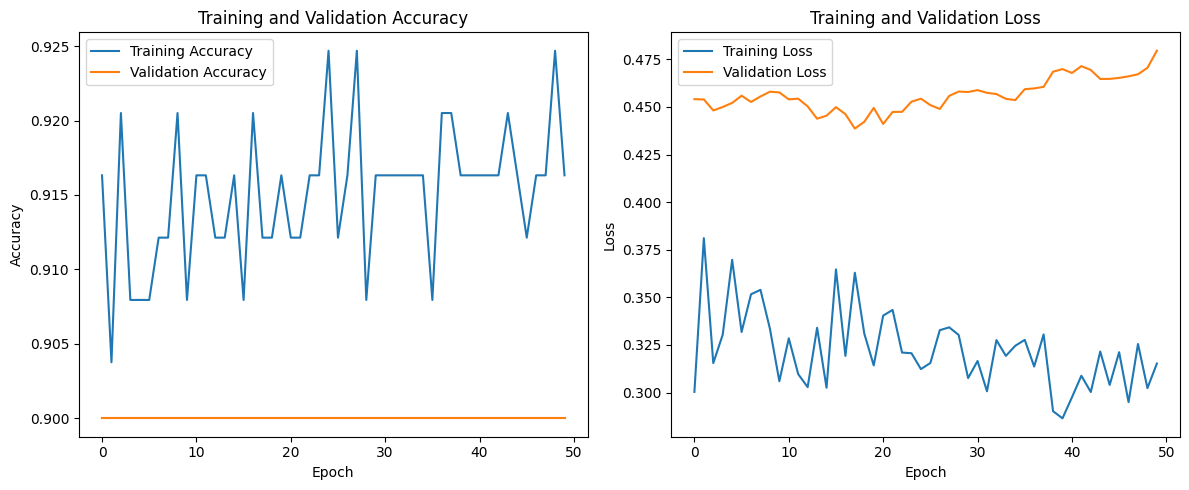

In [16]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
!pip install --ignore-installed blinker
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: starlette
    Found existing installation: starlette 1.6.0
    Uninstalling starlette-1.6.0:
      Successfully uninstalled starlette-1.6.0


In [23]:
!pip install streamlit pyngrok

In [24]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [28]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [29]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &




2026-08-19 12:40:03.051 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.235.245:8501

2026-08-19 12:40:12.088246: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
  Stopping...
